In [1]:
# ============================================================================
#  Sector Rotation: Which Sector Leads the Market?
#  Returns, Risk, Diversification, Regression & Efficient Frontier
# ============================================================================
#  Author    : Kesidis Angelos
#  ETFs      : XLK, XLE, XLV, XLF, XLY
#  Benchmark : S&P 500 (^GSPC)
#  Period    : 2015-01-01 to 2025-05-01
#  Purpose   : Log returns, risk metrics, covariance/correlation,
#              portfolio risk decomposition, regression (OLS),
#              beta/alpha analysis, Markowitz Efficient Frontier
# ============================================================================

In [2]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
import statsmodels.api as sm
 
%matplotlib inline

In [3]:
# ============================================================
# SECTION 1 — DATA COLLECTION & CLEANING
# ============================================================
 
etfs      = ["XLK", "XLE", "XLV", "XLF", "XLY"]   # sector ETFs
benchmark = ["^GSPC"]
assets    = etfs + benchmark                         # all tickers
 
start = "2015-01-01"
end   = "2025-05-01"
 
# Download closing prices for all assets
data = yf.download(assets, start=start, end=end)["Close"]
 
# Basic diagnostics
print("Shape   :", data.shape)
print("Columns :", list(data.columns))
print("\n--- First 5 rows ---")
print(data.head())
print("\n--- Last 5 rows ---")
print(data.tail())
print("\n--- Missing values per column ---")
print(data.isnull().sum())

[*********************100%***********************]  6 of 6 completed

Shape   : (2597, 6)
Columns : ['XLE', 'XLF', 'XLK', 'XLV', 'XLY', '^GSPC']

--- First 5 rows ---
Ticker            XLE        XLF        XLK        XLV        XLY        ^GSPC
Date                                                                          
2015-01-02  25.548063  16.274790  18.084276  57.057846  31.636650  2058.199951
2015-01-05  24.491192  15.932580  17.808216  56.766853  31.031572  2020.579956
2015-01-06  24.131401  15.689082  17.593493  56.575657  30.722403  2002.609985
2015-01-07  24.182806  15.853608  17.742487  57.905846  31.208246  2025.900024
2015-01-08  24.725693  16.090521  18.132479  58.895210  31.676411  2062.139893

--- Last 5 rows ---
Ticker            XLE        XLF         XLK         XLV        XLY  \
Date                                                                  
2025-04-24  39.986259  47.516258  102.131332  134.982666  96.293907   
2025-04-25  39.913589  47.289757  103.642700  135.631119  98.025230   
2025-04-28  40.194572  47.437469  103.473671 

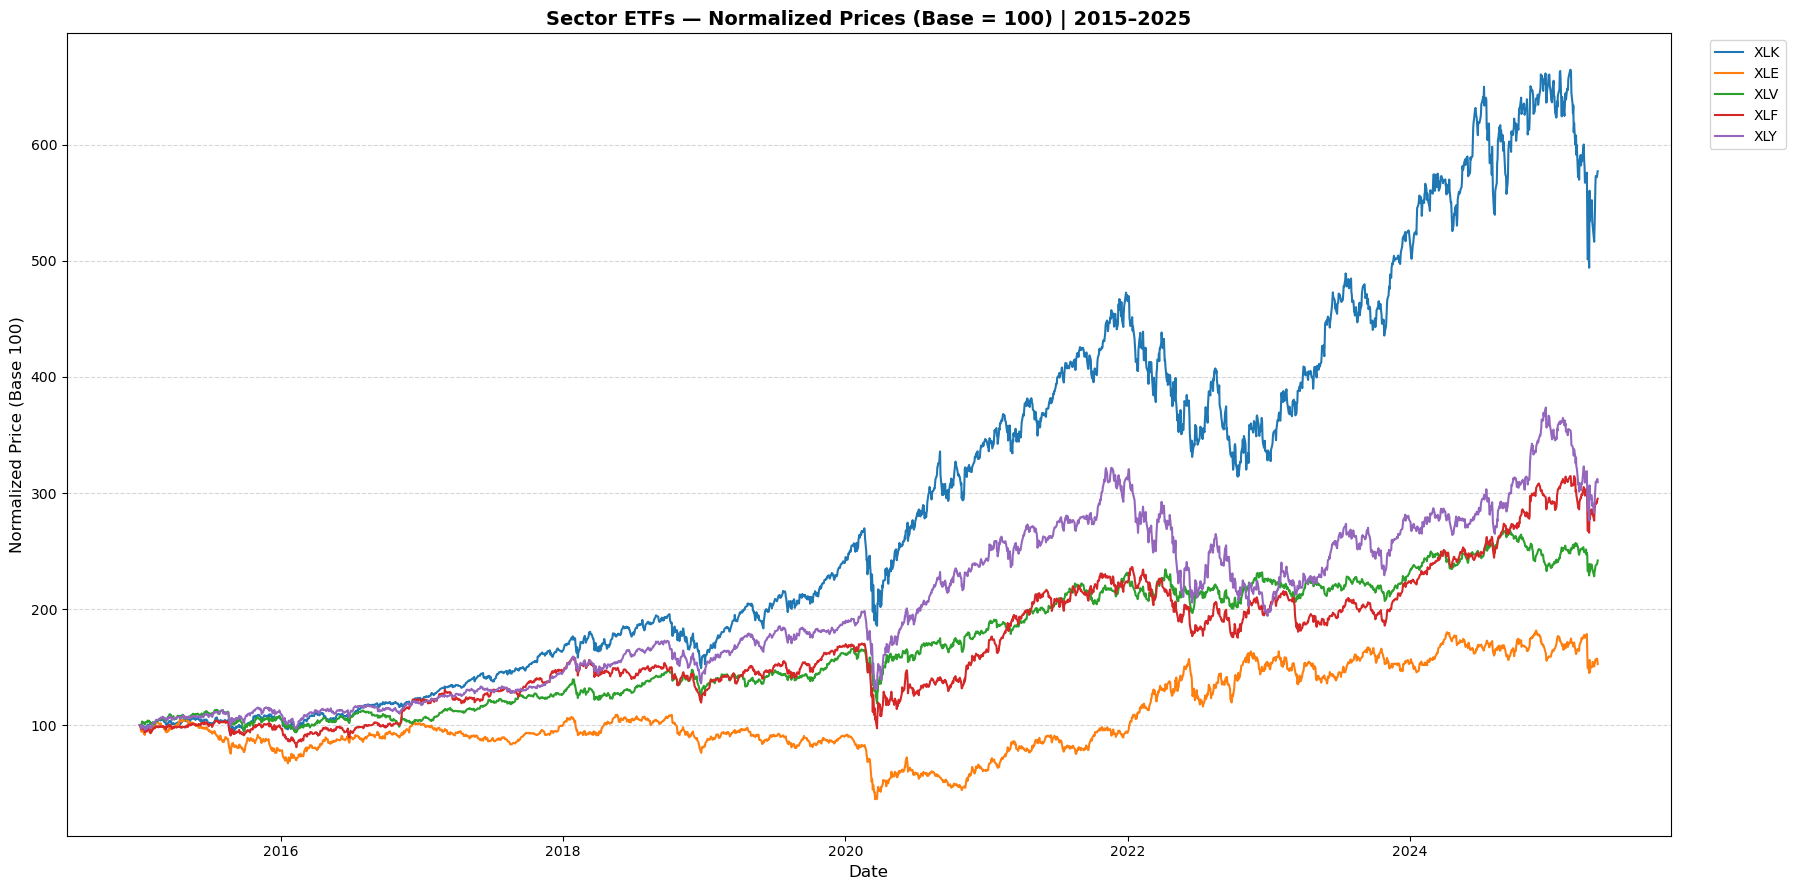

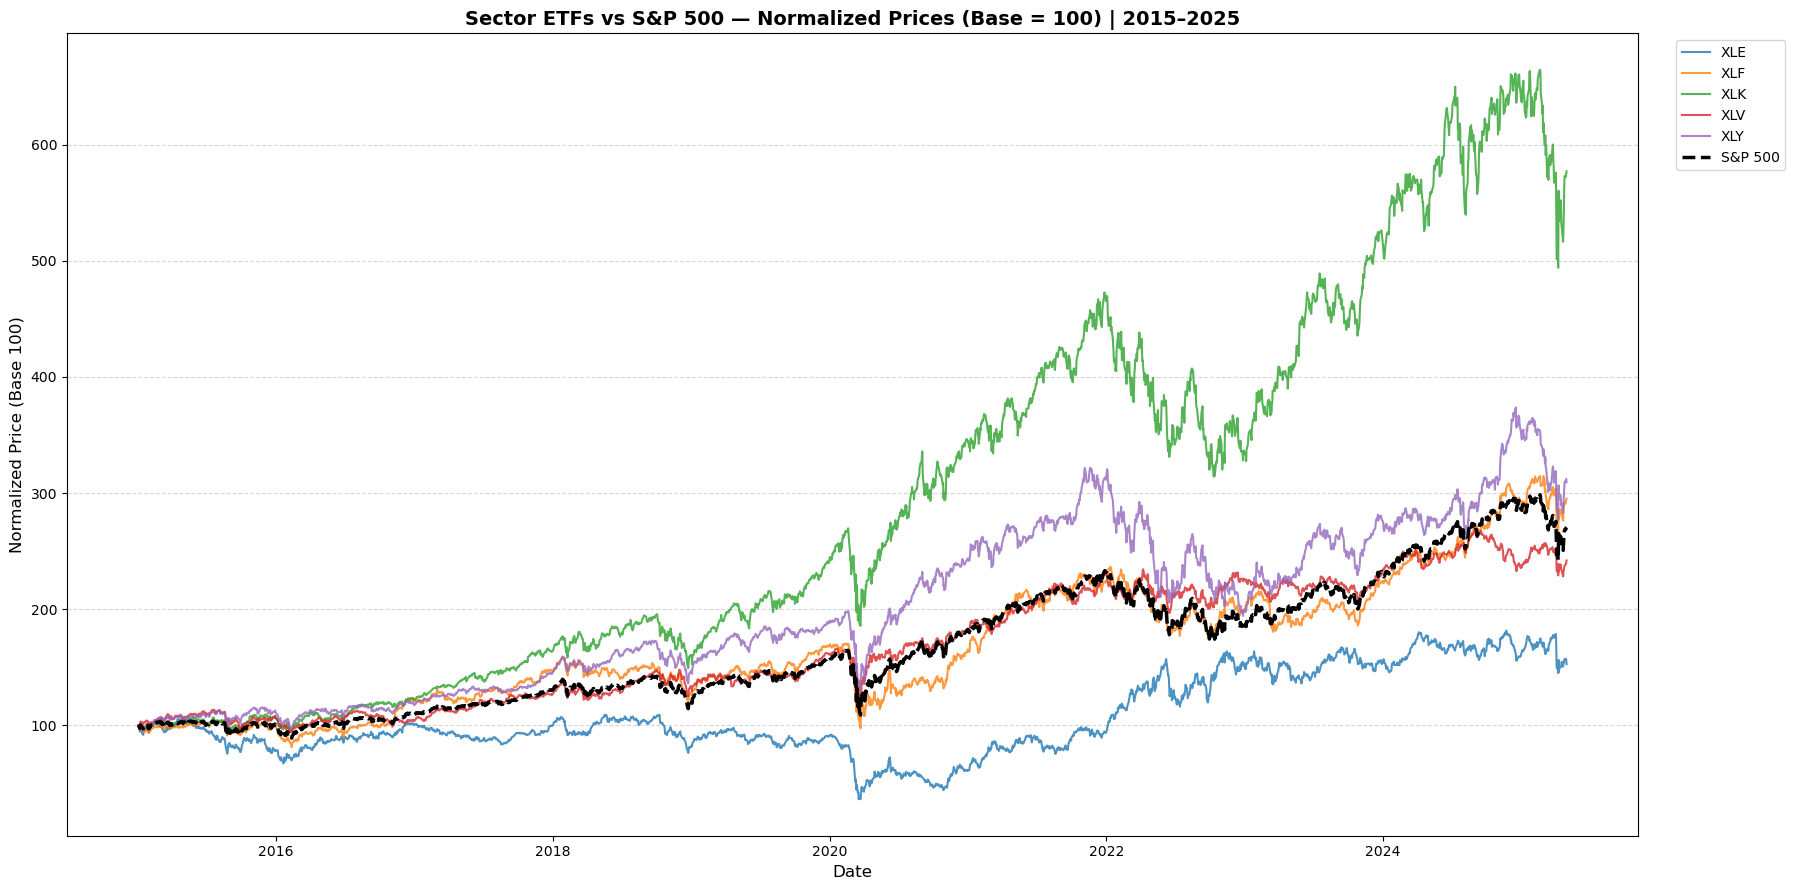

In [4]:
# ============================================================
# SECTION 2 — NORMALIZATION & VISUALIZATION
# ============================================================
 
# ── Plot 1: Sector ETFs only ──────────────────────────────────
normalized_etfs = (data[etfs] / data[etfs].iloc[0]) * 100
 
plt.figure(figsize=(18, 9))
for col in normalized_etfs.columns:
    plt.plot(normalized_etfs[col], label=col)
 
plt.title("Sector ETFs — Normalized Prices (Base = 100) | 2015–2025",
          fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Base 100)", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()
 
# ── Plot 2: Sector ETFs + S&P 500 — who leads the market? ────
normalized_all = (data / data.iloc[0]) * 100
 
plt.figure(figsize=(18, 9))
for col in normalized_all.columns:
    if col in benchmark:
        plt.plot(normalized_all[col], label="S&P 500",
                 linewidth=2.5, linestyle="--", color="black")
    else:
        plt.plot(normalized_all[col], label=col, alpha=0.8)
 
plt.title("Sector ETFs vs S&P 500 — Normalized Prices (Base = 100) | 2015–2025",
          fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Base 100)", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()


--- Daily Log Returns (first 5 rows) ---
Ticker           XLE       XLF       XLK       XLV       XLY     ^GSPC
Date                                                                  
2015-01-05 -0.042248 -0.021251 -0.015383 -0.005113 -0.019311 -0.018447
2015-01-06 -0.014800 -0.015401 -0.012131 -0.003374 -0.010013 -0.008933
2015-01-07  0.002128  0.010432  0.008433  0.023240  0.015690  0.011563
2015-01-08  0.022201  0.014833  0.021743  0.016941  0.014890  0.017730
2015-01-09 -0.007957 -0.013588 -0.003147 -0.008933 -0.011641 -0.008439


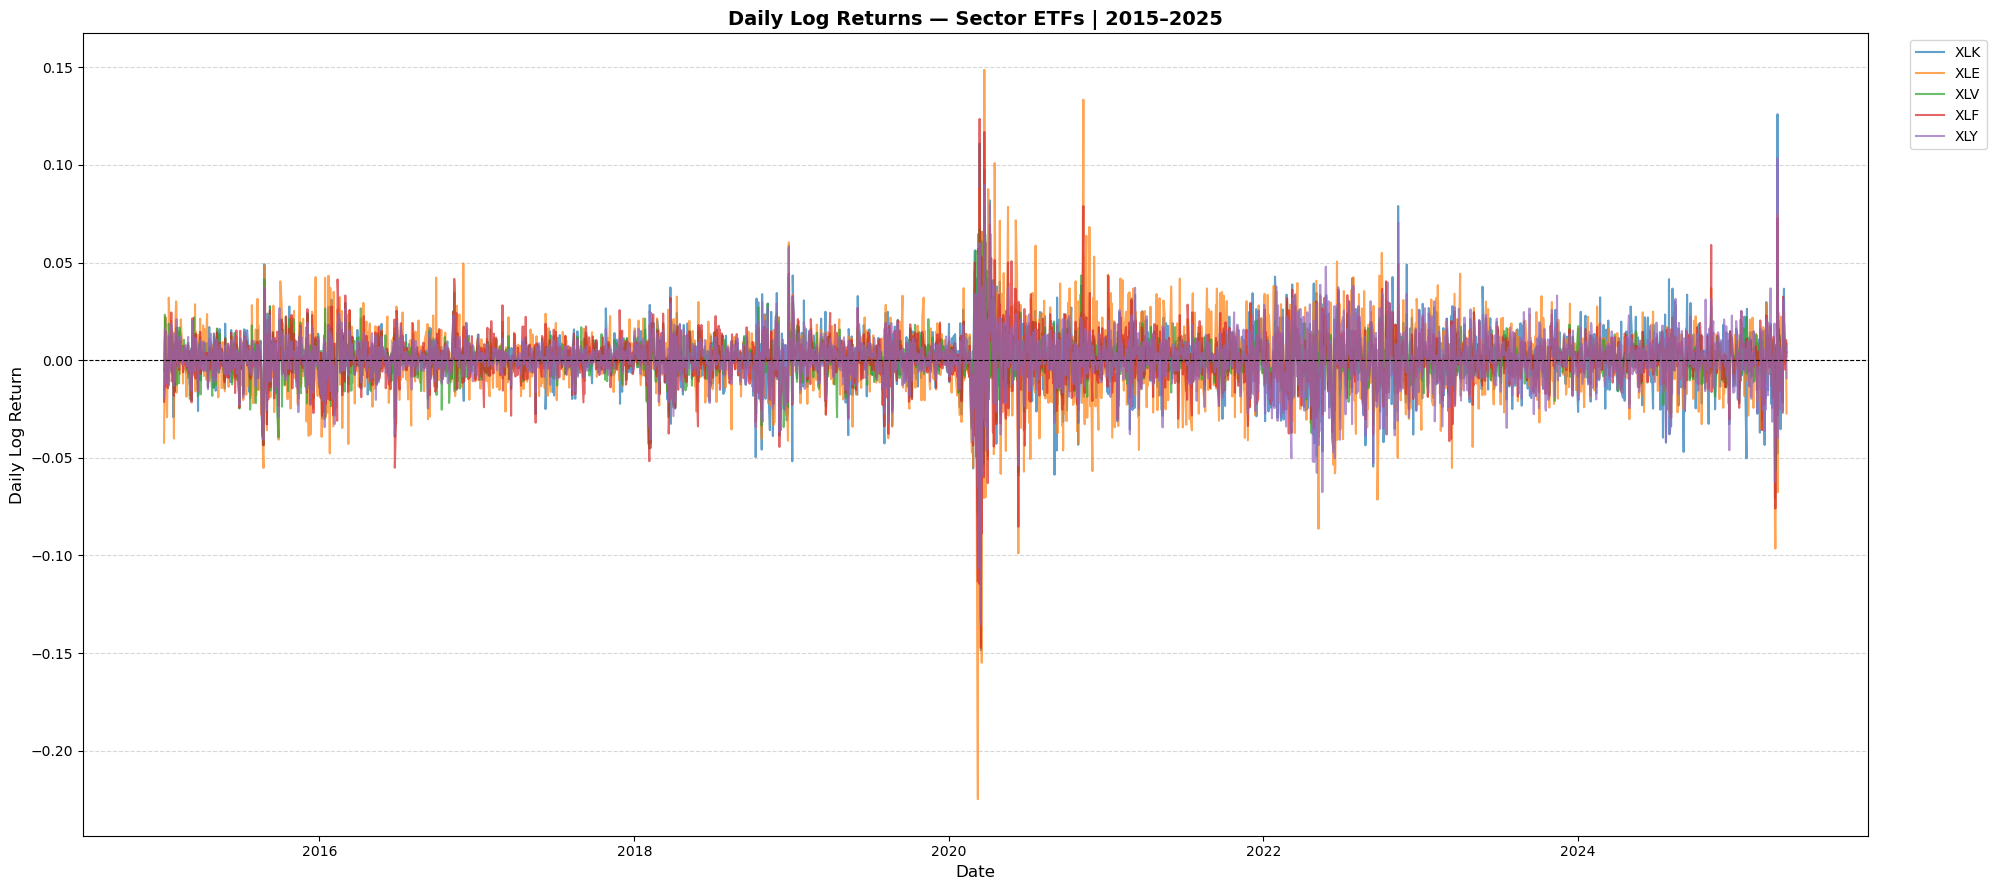


--- Sector ETF Annual Returns (Ranked) ---
       Annual Return (%)
Ticker                  
XLK               16.88%
XLY               10.87%
XLF               10.42%
XLV                8.51%
XLE                4.07%


In [5]:
# ============================================================
# SECTION 3 — RETURNS ANALYSIS
# ============================================================
 
# Daily log returns for all assets
log_return = np.log(data / data.shift(1)).dropna()
 
print("\n--- Daily Log Returns (first 5 rows) ---")
print(log_return.head())
 
# ── Plot: Daily Log Returns — Sector ETFs only ───────────────
plt.figure(figsize=(20, 9))
for col in etfs:
    plt.plot(log_return[col], label=col, alpha=0.7)
 
plt.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
plt.title("Daily Log Returns — Sector ETFs | 2015–2025", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Log Return", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()
 
# ── Annualized Returns (× 250 trading days) — ETFs only ──────
annual_return = log_return[etfs].mean() * 250
 
# Ranking table with % formatting
summary_returns = pd.DataFrame({
    "Annual Return (%)": (annual_return * 100).round(2)
}).sort_values(by="Annual Return (%)", ascending=False)
 
summary_returns_display = summary_returns.applymap(lambda x: f"{x}%")
print("\n--- Sector ETF Annual Returns (Ranked) ---")
print(summary_returns_display.to_string())

In [6]:
# ============================================================
# SECTION 4 — RISK ANALYSIS
# ============================================================
 
# Annual Std Dev and Variance — ETFs only
annual_std_dev  = log_return[etfs].std() * (250 ** 0.5)
annual_variance = log_return[etfs].var() * 250
 
# Risk ranking table — lowest to highest risk
risk_table = pd.DataFrame({
    "Annual Std Dev (%)":  (annual_std_dev  * 100).round(2),
    "Annual Variance (%)": (annual_variance * 100).round(2)
}).sort_values(by="Annual Std Dev (%)", ascending=True)
 
risk_table_display = risk_table.applymap(lambda x: f"{x}%")
print("\n--- Risk Analysis — Ranked Low to High ---")
print(risk_table_display.to_string())


--- Risk Analysis — Ranked Low to High ---
       Annual Std Dev (%) Annual Variance (%)
Ticker                                       
XLV                16.79%               2.82%
XLY                21.69%               4.71%
XLF                22.34%               4.99%
XLK                23.96%               5.74%
XLE                30.05%               9.03%



--- Annual Covariance Matrix ---
Ticker       XLK       XLE       XLV       XLF       XLY
Ticker                                                  
XLK     0.057398  0.033899  0.027802  0.036463  0.044127
XLE     0.033899  0.090273  0.024457  0.046572  0.032878
XLV     0.027802  0.024457  0.028196  0.026040  0.023978
XLF     0.036463  0.046572  0.026040  0.049914  0.035694
XLY     0.044127  0.032878  0.023978  0.035694  0.047066

--- Correlation Matrix ---
Ticker    XLK    XLE    XLV    XLF    XLY
Ticker                                   
XLK     1.000  0.471  0.691  0.681  0.849
XLE     0.471  1.000  0.485  0.694  0.504
XLV     0.691  0.485  1.000  0.694  0.658
XLF     0.681  0.694  0.694  1.000  0.736
XLY     0.849  0.504  0.658  0.736  1.000

Diagonal check (must all be 1.0): [1. 1. 1. 1. 1.]

Average Pairwise Correlation : 0.646
Observation: Sectors with low pairwise correlation offer real diversification benefit.


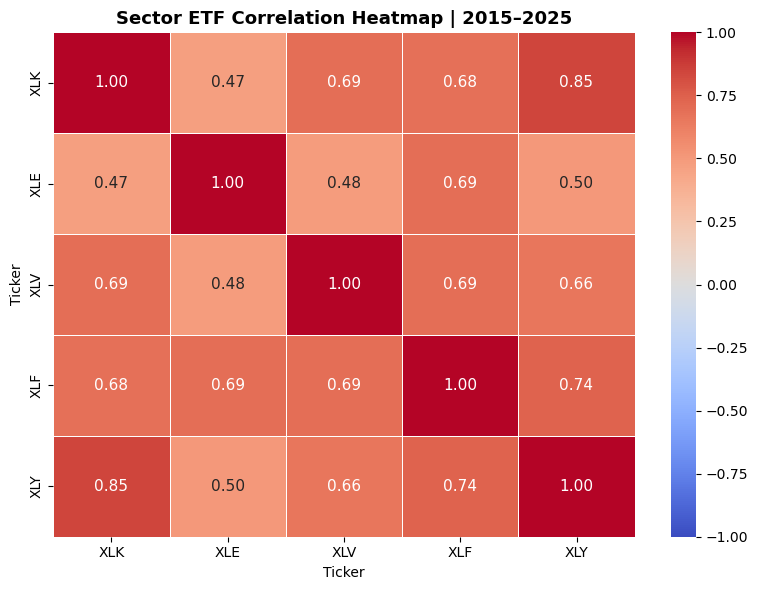

In [7]:
# ============================================================
# SECTION 5 — COVARIANCE & CORRELATION
# ============================================================
 
# Covariance matrix — annualized (× 250)
cov_matrix = log_return[etfs].cov() * 250
print("\n--- Annual Covariance Matrix ---")
print(cov_matrix.round(6))
 
# Correlation matrix — never annualized
corr_matrix = log_return[etfs].corr()
print("\n--- Correlation Matrix ---")
print(corr_matrix.round(3))
print("\nDiagonal check (must all be 1.0):", np.diag(corr_matrix.values).round(3))
 
# Average pairwise correlation (excluding diagonal)
mask = np.ones(corr_matrix.shape, dtype=bool)
np.fill_diagonal(mask, False)
avg_corr = corr_matrix.values[mask].mean()
print(f"\nAverage Pairwise Correlation : {round(avg_corr, 3)}")
print("Observation: Sectors with low pairwise correlation offer real diversification benefit.")
 
# ── Correlation Heatmap ───────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    annot_kws={"size": 11}
)
plt.title("Sector ETF Correlation Heatmap | 2015–2025", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# SECTION 6 — PORTFOLIO RISK (EQUAL WEIGHT)
# ============================================================
 
# Equal-weight portfolio — one fifth per sector
n = len(etfs)
weights_ew = np.array([1 / n] * n)
 
print(f"\nNumber of ETFs   : {n}")
print(f"Weight per ETF   : {round(weights_ew[0], 6)}")
print(f"Sum of weights   : {round(sum(weights_ew), 10)}")   # must equal 1.0
 
# Portfolio Variance and Volatility — matrix form: w^T · Σ · w
portfolio_variance   = np.dot(weights_ew.T, np.dot(cov_matrix, weights_ew))
portfolio_volatility = portfolio_variance ** 0.5
 
print("\n===== Equal-Weight Portfolio Variance & Volatility =====")
print(f"Portfolio Variance   : {portfolio_variance:.6f}")
print(f"Portfolio Volatility : {round(portfolio_volatility * 100, 2)}%")
 
# ── Systematic vs Diversifiable Risk ─────────────────────────
sr = np.sum(weights_ew ** 2 * annual_variance[etfs].values)
dr = portfolio_variance - sr
 
# Worst-case: all sectors perfectly correlated (ρ = 1)
worst_case_variance     = (np.sum(weights_ew * np.sqrt(annual_variance[etfs].values))) ** 2
diversification_benefit = worst_case_variance - portfolio_variance
diversification_ratio   = (diversification_benefit / worst_case_variance) * 100
 
print("\n===== Risk Decomposition =====")
print(f"Systematic Risk (SR)         : {round(sr * 100, 4)}%")
print(f"Diversifiable Risk (DR)      : {round(dr * 100, 4)}%")
print(f"Verification SR + DR         : {round((sr + dr) * 100, 4)}%  (= Portfolio Variance ✓)")
print(f"\nWorst-Case Variance (ρ=1)    : {worst_case_variance:.6f}")
print(f"Actual Portfolio Variance    : {portfolio_variance:.6f}")
print(f"Diversification Benefit      : {diversification_benefit:.6f}")
print(f"Diversification Ratio        : {round(diversification_ratio, 1)}%  (% of risk removed)")


Number of ETFs   : 5
Weight per ETF   : 0.2
Sum of weights   : 1.0

===== Equal-Weight Portfolio Variance & Volatility =====
Portfolio Variance   : 0.037467
Portfolio Volatility : 19.36%

===== Risk Decomposition =====
Systematic Risk (SR)         : 1.0914%
Diversifiable Risk (DR)      : 2.6553%
Verification SR + DR         : 3.7467%  (= Portfolio Variance ✓)

Worst-Case Variance (ρ=1)    : 0.052745
Actual Portfolio Variance    : 0.037467
Diversification Benefit      : 0.015278
Diversification Ratio        : 29.0%  (% of risk removed)


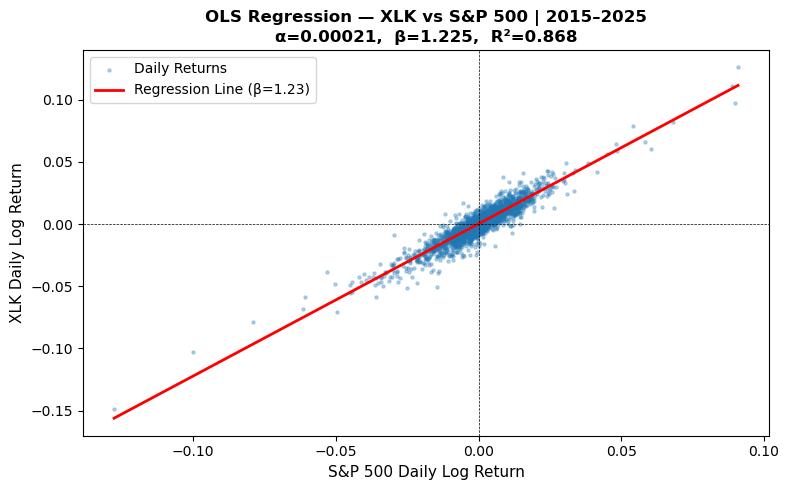

  XLK: β=1.225 > 1 → moves MORE than the market (aggressive)


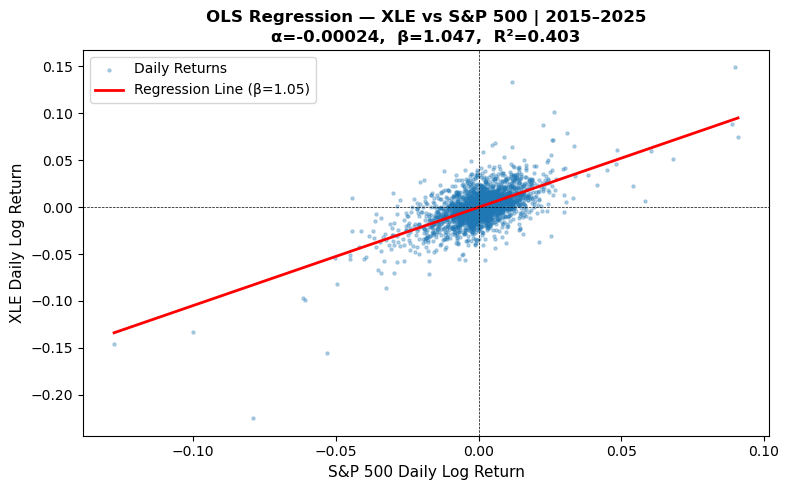

  XLE: β=1.047 > 1 → moves MORE than the market (aggressive)


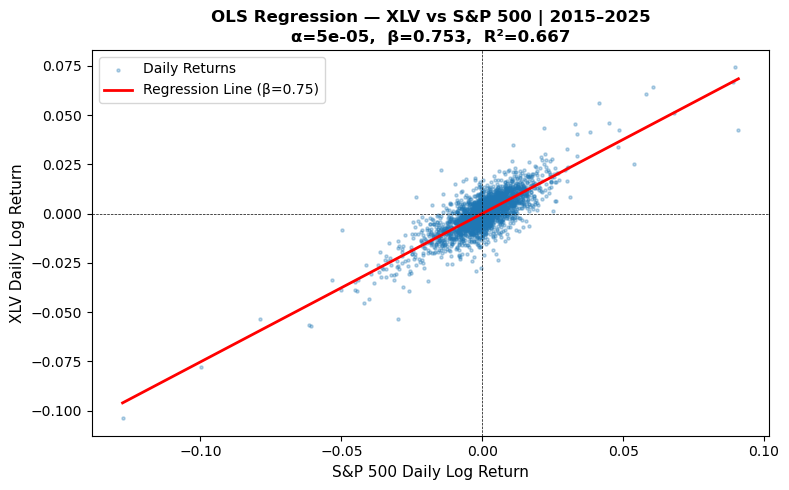

  XLV: β=0.753 < 1 → moves LESS than the market (defensive)


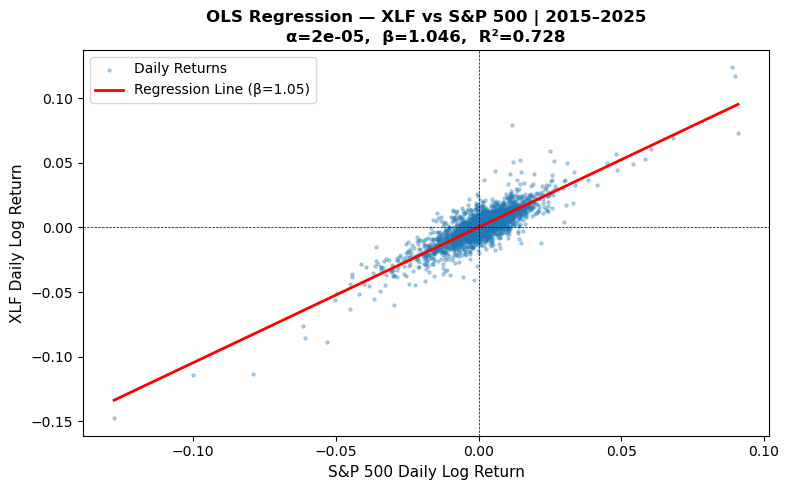

  XLF: β=1.046 > 1 → moves MORE than the market (aggressive)


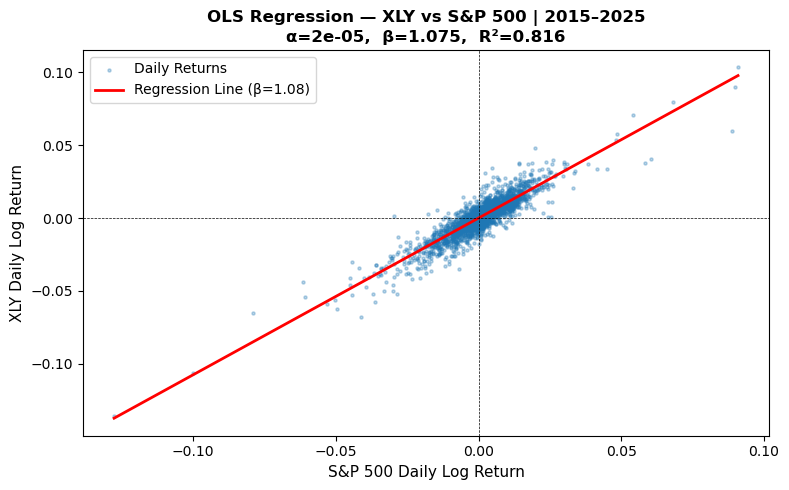

  XLY: β=1.075 > 1 → moves MORE than the market (aggressive)

  REGRESSION SUMMARY — Sector ETFs vs S&P 500 | 2015–2025
      Beta  Alpha (ann%)  R² (%)     Verdict
XLK  1.225         5.140   86.80  Aggressive
XLE  1.047        -5.965   40.33  Aggressive
XLV  0.753         1.289   66.74   Defensive
XLF  1.046         0.389   72.83  Aggressive
XLY  1.075         0.565   81.59  Aggressive

--- Verification: scipy vs statsmodels (XLF) ---
scipy       R² : 0.7283
statsmodels R² : 0.7283
Same value?    : True


In [9]:
# ============================================================
# SECTION 7 — REGRESSION ANALYSIS: Sector ETFs vs S&P 500
# ============================================================
# Goal: quantify each sector's sensitivity to the market (Beta),
# its excess return (Alpha), and how much is explained by S&P 500 (R²).
 
X_raw = log_return["^GSPC"]              # independent variable: market returns
X_c   = sm.add_constant(X_raw)           # add intercept — always required
 
regression_results = {}                  # store results for summary table
 
for etf in etfs:
    Y = log_return[etf]
 
    # ── scipy: quick metrics ──────────────────────────────────
    slope, intercept, r_value, p_value, std_err = stats.linregress(X_raw, Y)
 
    # ── statsmodels: full OLS analysis ───────────────────────
    model = sm.OLS(Y, X_c).fit()
 
    # Store results — alpha annualized: daily intercept × 250 × 100
    regression_results[etf] = {
        "Beta":         round(model.params["^GSPC"], 3),
        "Alpha (ann%)": round(model.params["const"] * 250 * 100, 3),
        "R² (%)":       round(model.rsquared * 100, 2),
        "p-value":      round(model.pvalues["^GSPC"], 6)
    }
 
    # ── Scatter plot with regression line ────────────────────
    x_line = np.linspace(X_raw.min(), X_raw.max(), 100)
    y_line = intercept + slope * x_line
 
    plt.figure(figsize=(8, 5))
    plt.scatter(X_raw, Y, alpha=0.3, s=5, label="Daily Returns")
    plt.plot(x_line, y_line, color="red", linewidth=2,
             label=f"Regression Line (β={round(slope, 2)})")
    plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
    plt.axvline(0, color="black", linewidth=0.5, linestyle="--")
    plt.xlabel("S&P 500 Daily Log Return", fontsize=11)
    plt.ylabel(f"{etf} Daily Log Return", fontsize=11)
    plt.title(f"OLS Regression — {etf} vs S&P 500 | 2015–2025\n"
              f"α={round(intercept,5)},  β={round(slope,3)},  R²={round(r_value**2,3)}",
              fontsize=12, fontweight="bold")
    plt.legend()
    plt.tight_layout()
    plt.show()
 
    # ── Beta interpretation ───────────────────────────────────
    beta = regression_results[etf]["Beta"]
    if beta > 1:
        interpretation = f"β={beta} > 1 → moves MORE than the market (aggressive)"
    elif beta < 1:
        interpretation = f"β={beta} < 1 → moves LESS than the market (defensive)"
    else:
        interpretation = f"β={beta} = 1 → moves exactly like the market"
    print(f"  {etf}: {interpretation}")
 
# ── Regression Summary Table ──────────────────────────────────
reg_df = pd.DataFrame(regression_results).T
reg_df["Verdict"] = reg_df["Beta"].apply(
    lambda b: "Aggressive" if float(b) > 1 else "Defensive"
)
 
print("\n" + "=" * 65)
print("  REGRESSION SUMMARY — Sector ETFs vs S&P 500 | 2015–2025")
print("=" * 65)
print(reg_df[["Beta", "Alpha (ann%)", "R² (%)", "Verdict"]].to_string())
print("=" * 65)
 
# ── Cross-verification: scipy vs statsmodels (XLF) ───────────
print("\n--- Verification: scipy vs statsmodels (XLF) ---")
slope_v, _, r_v, _, _ = stats.linregress(X_raw, log_return["XLF"])
model_v = sm.OLS(log_return["XLF"], X_c).fit()
print(f"scipy       R² : {round(r_v**2, 4)}")
print(f"statsmodels R² : {round(model_v.rsquared, 4)}")
print(f"Same value?    : {round(r_v**2, 4) == round(model_v.rsquared, 4)}")


===== Individual Sector Risk & Return Summary =====
        Annual Return (%)  Annual Variance  Volatility / Risk (%)  Sharpe Ratio
Ticker                                                                         
XLK                 16.88         0.057398                  23.96         0.517
XLE                  4.07         0.090273                  30.05        -0.014
XLV                  8.51         0.028196                  16.79         0.239
XLF                 10.42         0.049914                  22.34         0.265
XLY                 10.87         0.047066                  21.69         0.294

Max Return    : 14.64 %
Min Volatility: 16.64 %

Minimum Variance Portfolio (MVP):
Return         9.01
Volatility    16.64
Name: 8530, dtype: float64

Maximum Return Portfolio (MRP):
Return        14.64
Volatility    21.39
Name: 5730, dtype: float64

--- Equal-Weight Portfolio ---
Return    : 10.15%
Volatility: 19.36%
Sharpe    : 0.292


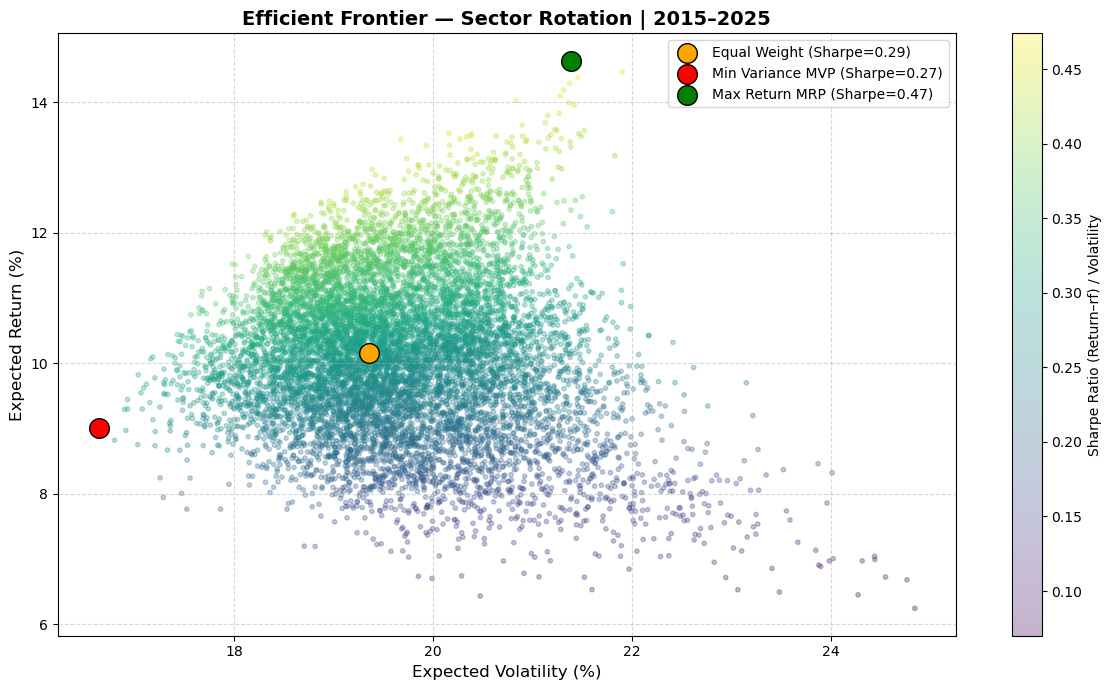


===== Optimal Weights: MVP vs MRP =====
Asset  MVP_Weight  MRP_Weight
  XLV       77.47        9.07
  XLY       15.50        1.21
  XLF        3.68       17.22
  XLK        1.69       70.15
  XLE        1.66        2.35


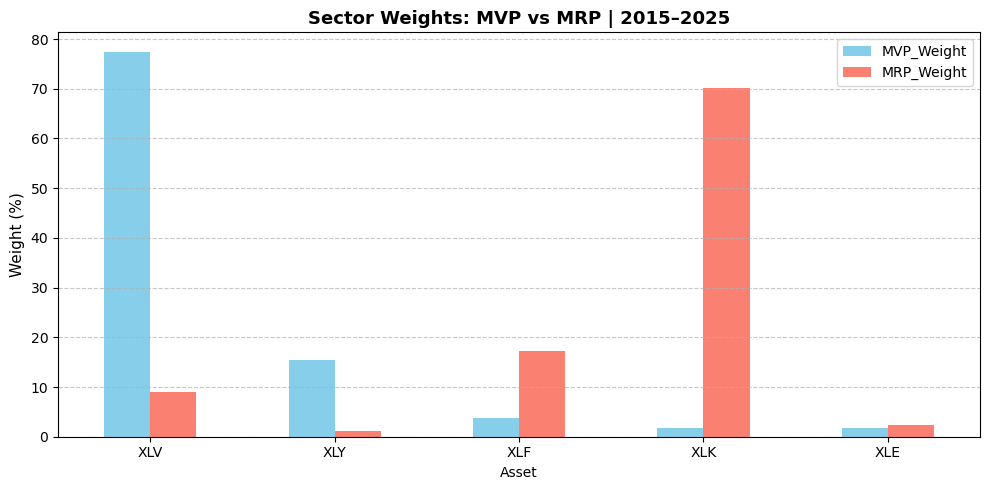

In [10]:
# ============================================================
# SECTION 8 — EFFICIENT FRONTIER (MONTE CARLO SIMULATION)
# ============================================================
# Markowitz (1952): by varying portfolio weights we can map
# all achievable risk-return combinations — the Efficient Frontier.
 
rf = 0.045   # risk-free rate (approximate 10-year US Treasury yield)
 
# Individual asset Sharpe Ratios for reference
sharpe_individual = (annual_return - rf) / annual_std_dev
 
summary_individual = pd.DataFrame({
    "Annual Return (%)":    (annual_return   * 100).round(2),
    "Annual Variance":       annual_variance.round(6),
    "Volatility / Risk (%)": (annual_std_dev  * 100).round(2),
    "Sharpe Ratio":          sharpe_individual.round(3)
})
print("\n===== Individual Sector Risk & Return Summary =====")
print(summary_individual.to_string())
 
# ── Monte Carlo: 10,000 random portfolios ────────────────────
cov_matrix_annual = log_return[etfs].cov() * 250   # annualized cov matrix
num_assets = len(etfs)
 
portfolio_returns_list      = []
portfolio_volatilities_list = []
portfolio_weights_list      = []
 
for _ in range(10000):
    w  = np.random.random(num_assets)
    w /= np.sum(w)                                   # enforce Σw = 1
 
    p_ret = np.sum(w * log_return[etfs].mean() * 250)
    p_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix_annual, w)))
 
    portfolio_returns_list.append(p_ret)
    portfolio_volatilities_list.append(p_vol)
    portfolio_weights_list.append(w)
 
portfolio_returns_arr      = np.array(portfolio_returns_list)
portfolio_volatilities_arr = np.array(portfolio_volatilities_list)
 
print("\nMax Return    :", round(portfolio_returns_arr.max()      * 100, 2), "%")
print("Min Volatility:", round(portfolio_volatilities_arr.min() * 100, 2), "%")
 
# Build DataFrame
portfolios = pd.DataFrame({
    "Return":     portfolio_returns_arr,
    "Volatility": portfolio_volatilities_arr
})
 
# ── Key portfolios ────────────────────────────────────────────
mvp_idx = portfolios["Volatility"].idxmin()   # Minimum Variance Portfolio
mrp_idx = portfolios["Return"].idxmax()        # Maximum Return Portfolio
 
MVP = portfolios.loc[mvp_idx]
MRP = portfolios.loc[mrp_idx]
 
best_weights_mvp = portfolio_weights_list[mvp_idx]
best_weights_mrp = portfolio_weights_list[mrp_idx]
 
print("\nMinimum Variance Portfolio (MVP):")
print(round(MVP * 100, 2))
print("\nMaximum Return Portfolio (MRP):")
print(round(MRP * 100, 2))
 
# ── Equal-weight portfolio point ─────────────────────────────
ew_ret = np.sum(weights_ew * log_return[etfs].mean() * 250)
ew_vol = np.sqrt(np.dot(weights_ew.T, np.dot(cov_matrix_annual, weights_ew)))
ew_sharpe = (ew_ret - rf) / ew_vol
 
print(f"\n--- Equal-Weight Portfolio ---")
print(f"Return    : {round(ew_ret * 100, 2)}%")
print(f"Volatility: {round(ew_vol * 100, 2)}%")
print(f"Sharpe    : {round(ew_sharpe, 3)}")
 
# ── Efficient Frontier Plot ───────────────────────────────────
plt.figure(figsize=(12, 7))
 
# Layer 1: 10,000 random portfolios — colored by Sharpe Ratio
sharpe_sim = (portfolios["Return"] - rf) / portfolios["Volatility"]
sc = plt.scatter(
    portfolios["Volatility"] * 100, portfolios["Return"] * 100,
    c=sharpe_sim, marker="o", s=10, alpha=0.3, cmap="viridis"
)
 
# Layer 2: Equal Weight portfolio
plt.scatter(ew_vol * 100, ew_ret * 100,
            color="orange", marker="o", s=200, zorder=5,
            edgecolor="black", label=f"Equal Weight (Sharpe={round(ew_sharpe,2)})")
 
# Layer 3: Minimum Variance Portfolio
mvp_sharpe = (MVP["Return"] - rf) / MVP["Volatility"]
plt.scatter(MVP["Volatility"] * 100, MVP["Return"] * 100,
            color="red", marker="o", s=200, zorder=5,
            edgecolor="black", label=f"Min Variance MVP (Sharpe={round(mvp_sharpe,2)})")
 
# Layer 4: Maximum Return Portfolio
mrp_sharpe = (MRP["Return"] - rf) / MRP["Volatility"]
plt.scatter(MRP["Volatility"] * 100, MRP["Return"] * 100,
            color="green", marker="o", s=200, zorder=5,
            edgecolor="black", label=f"Max Return MRP (Sharpe={round(mrp_sharpe,2)})")
 
plt.colorbar(sc, label="Sharpe Ratio (Return–rf) / Volatility")
plt.title("Efficient Frontier — Sector Rotation | 2015–2025",
          fontsize=14, fontweight="bold")
plt.xlabel("Expected Volatility (%)", fontsize=12)
plt.ylabel("Expected Return (%)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
 
# ── Optimal Weights Table ─────────────────────────────────────
weights_df = pd.DataFrame({
    "Asset":      etfs,
    "MVP_Weight": (best_weights_mvp * 100).round(2),
    "MRP_Weight": (best_weights_mrp * 100).round(2)
})
 
print("\n===== Optimal Weights: MVP vs MRP =====")
print(weights_df.sort_values(by="MVP_Weight", ascending=False).to_string(index=False))
 
weights_df.set_index("Asset").sort_values(by="MVP_Weight", ascending=False).plot(
    kind="bar", figsize=(10, 5), color=["skyblue", "salmon"]
)
plt.title("Sector Weights: MVP vs MRP | 2015–2025", fontsize=13, fontweight="bold")
plt.ylabel("Weight (%)", fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


===== PORTFOLIO COMPARISON =====
                    Return (%)  Volatility (%)  Sharpe Ratio
Portfolio                                                   
Equal Weight (EW)        10.15           19.36          0.29
Min Variance (MVP)        9.01           16.64          0.27
S&P 500                   9.59           18.22          0.28


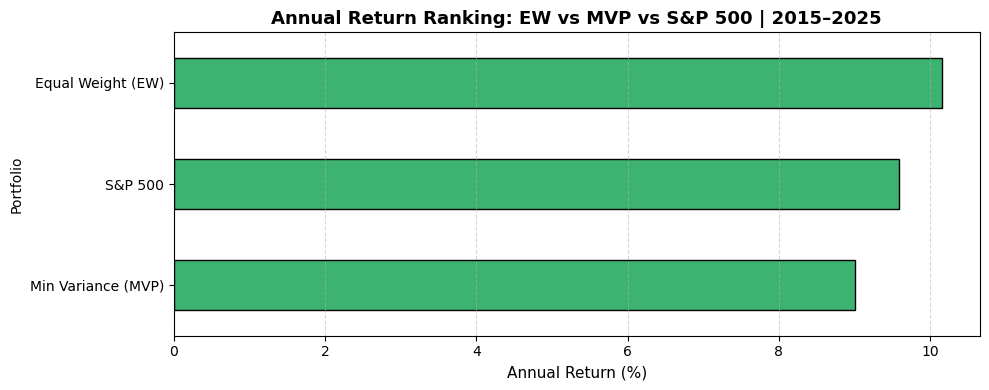

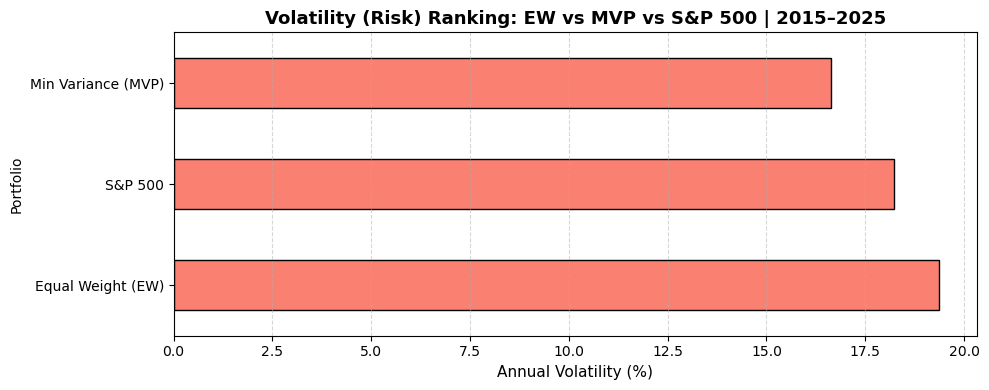

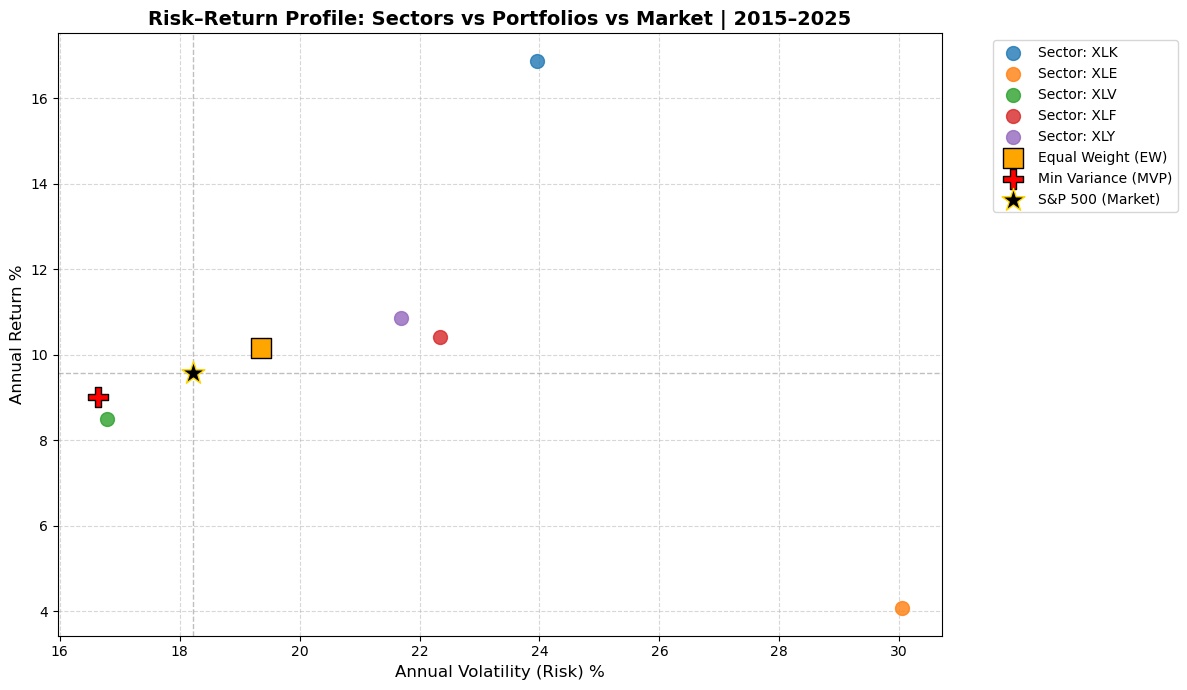

In [11]:
# ============================================================
# SECTION 9 — PORTFOLIO COMPARISON: EW vs MVP vs S&P 500
# ============================================================
 
sp500_ret = log_return["^GSPC"].mean() * 250
sp500_vol = log_return["^GSPC"].std()  * (250 ** 0.5)
sp500_sharpe = (sp500_ret - rf) / sp500_vol
 
comp_df = pd.DataFrame({
    "Portfolio":      ["Equal Weight (EW)", "Min Variance (MVP)", "S&P 500"],
    "Return (%)":     [round(ew_ret * 100, 2),
                       round(MVP["Return"] * 100, 2),
                       round(sp500_ret * 100, 2)],
    "Volatility (%)": [round(ew_vol * 100, 2),
                       round(MVP["Volatility"] * 100, 2),
                       round(sp500_vol * 100, 2)],
    "Sharpe Ratio":   [round(ew_sharpe, 3),
                       round(mvp_sharpe, 3),
                       round(sp500_sharpe, 3)]
}).set_index("Portfolio")
 
print("\n===== PORTFOLIO COMPARISON =====")
print(comp_df.round(2))
 
# ── Bar Chart 1: Returns Ranking ─────────────────────────────
comp_df["Return (%)"].sort_values().plot(
    kind="barh", figsize=(10, 4), color="mediumseagreen", edgecolor="black")
plt.title("Annual Return Ranking: EW vs MVP vs S&P 500 | 2015–2025",
          fontsize=13, fontweight="bold")
plt.xlabel("Annual Return (%)", fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
 
# ── Bar Chart 2: Volatility Ranking ──────────────────────────
comp_df["Volatility (%)"].sort_values(ascending=False).plot(
    kind="barh", figsize=(10, 4), color="salmon", edgecolor="black")
plt.title("Volatility (Risk) Ranking: EW vs MVP vs S&P 500 | 2015–2025",
          fontsize=13, fontweight="bold")
plt.xlabel("Annual Volatility (%)", fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
 
# ── Scatter: All Sectors + EW + MVP + S&P 500 ────────────────
plt.figure(figsize=(12, 7))
 
for etf in etfs:
    plt.scatter(annual_std_dev[etf] * 100, annual_return[etf] * 100,
                s=100, alpha=0.8, zorder=4, label=f"Sector: {etf}")
 
plt.scatter(ew_vol * 100, ew_ret * 100,
            color="orange", marker="s", s=200, edgecolor="black",
            zorder=5, label="Equal Weight (EW)")
plt.scatter(MVP["Volatility"] * 100, MVP["Return"] * 100,
            color="red", marker="P", s=200, edgecolor="black",
            zorder=5, label="Min Variance (MVP)")
plt.scatter(sp500_vol * 100, sp500_ret * 100,
            color="black", marker="*", s=300, edgecolor="gold",
            zorder=5, label="S&P 500 (Market)")
 
# Reference lines for S&P 500 risk and return
plt.axhline(sp500_ret * 100, color="gray", linestyle="--", linewidth=1, alpha=0.5)
plt.axvline(sp500_vol * 100, color="gray", linestyle="--", linewidth=1, alpha=0.5)
 
plt.title("Risk–Return Profile: Sectors vs Portfolios vs Market | 2015–2025",
          fontsize=14, fontweight="bold")
plt.xlabel("Annual Volatility (Risk) %", fontsize=12)
plt.ylabel("Annual Return %", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# SECTION 10 — CONCLUSIONS (Dynamic — driven by real numbers)
# ============================================================
 
print("\n" + "=" * 65)
print("  CONCLUSIONS — Sector Rotation: Which Sector Leads?")
print("=" * 65)
 
# 1. Return winners/losers
max_ret_sector = annual_return.idxmax()
min_ret_sector = annual_return.idxmin()
print(f"\n1. RETURNS: Best sector → {max_ret_sector} "
      f"({round(annual_return[max_ret_sector]*100,2)}%) | "
      f"Worst → {min_ret_sector} "
      f"({round(annual_return[min_ret_sector]*100,2)}%)")
 
# 2. Most defensive sector by Beta
min_beta_sector = reg_df["Beta"].astype(float).idxmin()
min_beta_val    = reg_df.loc[min_beta_sector, "Beta"]
print(f"\n2. BETA (Defensive): {min_beta_sector} has the lowest Beta ({min_beta_val}). "
      f"It is least sensitive to broad market swings — ideal for risk-averse allocations.")
 
# 3. Most independent sector by R²
min_r2_sector = reg_df["R² (%)"].astype(float).idxmin()
min_r2_val    = reg_df.loc[min_r2_sector, "R² (%)"]
print(f"\n3. R² (Independence): {min_r2_sector} has the lowest R² ({min_r2_val}%). "
      f"The S&P 500 explains only {min_r2_val}% of its variance — "
      f"strongest diversification candidate in this portfolio.")
 
# 4. Equal Weight positioning on the frontier
print(f"\n4. EQUAL WEIGHT PORTFOLIO:")
print(f"   Return: {round(ew_ret*100,2)}% | Volatility: {round(ew_vol*100,2)}% | "
      f"Sharpe: {round(ew_sharpe,3)}")
print(f"   The EW portfolio sits inside the Efficient Frontier — sub-optimal.")
print(f"   Optimization (MVP/MRP) achieves better risk-return than naive equal weighting.")
 
# 5. MVP weights — which sector does the algorithm prefer?
top_mvp_asset  = weights_df.loc[weights_df["MVP_Weight"].idxmax(), "Asset"]
top_mvp_weight = weights_df["MVP_Weight"].max()
print(f"\n5. MVP PREFERENCES: The algorithm allocates the most weight to "
      f"{top_mvp_asset} ({top_mvp_weight}%) to minimize portfolio risk. "
      f"This sector has the lowest volatility and/or most negative covariance "
      f"with the others.")
 
# 6. Sector Rotation vs passive S&P 500 investing
best_sharpe  = max(ew_sharpe, mvp_sharpe, mrp_sharpe)
worth_it     = best_sharpe > sp500_sharpe
print(f"\n6. SECTOR ROTATION vs S&P 500 INDEXING:")
print(f"   S&P 500 Sharpe   : {round(sp500_sharpe, 3)}")
print(f"   Best Sim Sharpe  : {round(best_sharpe, 3)}")
if worth_it:
    print("   → WORTH IT: Optimized Sector Rotation beats the S&P 500 "
          "on a risk-adjusted basis over this period.")
else:
    print("   → NOT WORTH IT on pure Sharpe: The S&P 500 offers a better "
          "risk-adjusted return. Active sector rotation incurs higher costs "
          "and complexity — passive indexing is hard to beat consistently.")
 
print("\n   Key Takeaway: Sector Rotation adds value in specific market regimes,")
print("   but requires dynamic rebalancing (not captured in this static analysis).")
print("=" * 65)


  CONCLUSIONS — Sector Rotation: Which Sector Leads?

1. RETURNS: Best sector → XLK (16.88%) | Worst → XLE (4.07%)

2. BETA (Defensive): XLV has the lowest Beta (0.753). It is least sensitive to broad market swings — ideal for risk-averse allocations.

3. R² (Independence): XLE has the lowest R² (40.33%). The S&P 500 explains only 40.33% of its variance — strongest diversification candidate in this portfolio.

4. EQUAL WEIGHT PORTFOLIO:
   Return: 10.15% | Volatility: 19.36% | Sharpe: 0.292
   The EW portfolio sits inside the Efficient Frontier — sub-optimal.
   Optimization (MVP/MRP) achieves better risk-return than naive equal weighting.

5. MVP PREFERENCES: The algorithm allocates the most weight to XLV (77.47%) to minimize portfolio risk. This sector has the lowest volatility and/or most negative covariance with the others.

6. SECTOR ROTATION vs S&P 500 INDEXING:
   S&P 500 Sharpe   : 0.279
   Best Sim Sharpe  : 0.474
   → WORTH IT: Optimized Sector Rotation beats the S&P 500 on 